In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_regression

In [2]:
X , y = make_regression(n_samples = 100 , n_features = 1 , n_informative = 1 , n_targets = 1 , noise = 20 , random_state = 2)

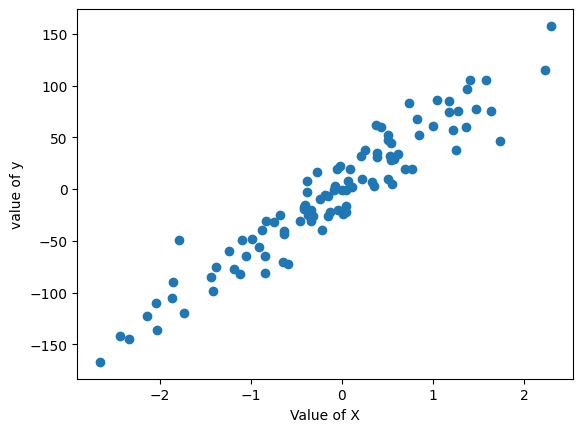

In [3]:
plt.scatter(X , y)
plt.xlabel("Value of X")
plt.ylabel("value of y")
plt.show()

<h2 style = "color:green;"> Using Normal Linear regression class </h2>

In [4]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()

lr_reg.fit(X , y)

LinearRegression()

In [5]:
print(f"Coefficients: {lr_reg.coef_}")
print(f"Intercept: {lr_reg.intercept_}")

Coefficients: [58.11865999]
Intercept: 0.5334392393890024


<h2 style = "color:green;"> Using Ridge regression class </h2>

In [6]:
from sklearn.linear_model import Ridge

rid_lr = Ridge(alpha = 10) # setting lambda = 10

rid_lr.fit(X , y)

Ridge(alpha=10)

In [7]:
print(f"Coefficients: {rid_lr.coef_}")
print(f"Intercept: {rid_lr.intercept_}")

Coefficients: [53.17425635]
Intercept: 0.020501198988965186


In [8]:
from sklearn.linear_model import Ridge

rid_lr2 = Ridge(alpha = 100) # setting lambda = 100

rid_lr2.fit(X , y)

print(f"Coefficients: {rid_lr2.coef_}")
print(f"Intercept: {rid_lr2.intercept_}")

Coefficients: [30.11564938]
Intercept: -2.371624834224593


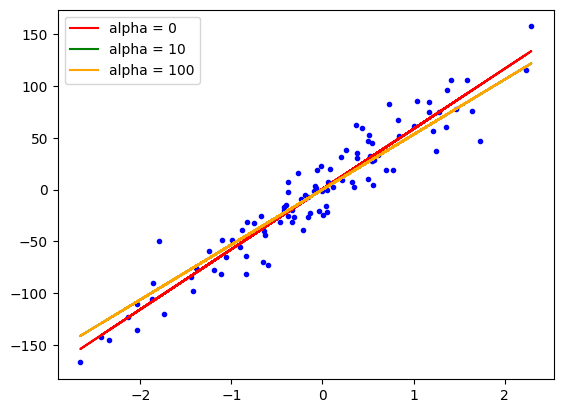

In [13]:
plt.plot(X , y , 'b. ')
plt.plot(X , lr_reg.predict(X) , color = 'red' , label = 'alpha = 0')
plt.plot(X , rid_lr.predict(X) , color = 'green' , label = 'alpha = 10')
plt.plot(X , rid_lr.predict(X) , color = 'orange' , label = 'alpha = 100') 

plt.legend()
plt.show()

<h3> Note: Green Line overlap's with orange one </h3>

<h3 style = "color:green"> Let's Build our own[for single variable]  </h3>

In [29]:
class MyRidge:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        X_train_mean = X_train.mean()
        y_train_mean = y_train.mean()
        num , den = 0 , 0 

        for i in range(X_train.shape[0]):
            num = num + ((y_train[i] - y_train_mean) * (X_train[i] - X_train_mean))
            den = den + ((X_train[i] - X_train_mean) ** 2)

        self.m = num / (den + self.alpha)
        self.b = y_train_mean - (self.m * X_train_mean)

        print(f"m : {self.m} , b: {self.b}")
        
    def predict(self, X_test):
        return self.m * X_test + self.b

In [30]:
my_ridge = MyRidge(alpha = 10)

my_ridge.fit(X , y) 

m : [53.17425635] , b: [0.0205012]


In [31]:
t = np.array([5,6])

print(f"sklearn predcit: {rid_lr.predict(t.reshape((-1 , 1)))}")
print(f"sklearn predcit: {rid_lr2.predict(t.reshape((-1 , 1)))}")
print(f"my_ridge predcit: {my_ridge.predict(t)}")

sklearn predcit: [265.89178295 319.0660393 ]
sklearn predcit: [148.20662205 178.32227142]
my_ridge predcit: [265.89178295 319.0660393 ]
